In [26]:
# Импортируем необходимые библиотеки для доступа к API МКС:
import requests # собственно, библиотека для доступа к странице:
import json # библиотека для приведения полученной информации в формат json (dict в Python)

mks_data = requests.get('http://api.open-notify.org/iss-now.json').text # обращаемся к API и получаем текст результата:
mks_data = json.loads(mks_data) # переводим в формат json (dict в Python)

print(mks_data)

{'timestamp': 1785838150, 'message': 'success', 'iss_position': {'longitude': '4.1954', 'latitude': '43.4671'}}


In [27]:
# импортируем библиотеку для работы с MongoDB из Python:
import pymongo

# подключаемся к базе данных:
myclient = pymongo.MongoClient("mongodb://localhost:27017/")
mydb = myclient["test"]
mycol = mydb["mks_data"]

In [28]:
# добавляем значение, полученное в прошлом куске кода:
mycol.insert_one(mks_data)

InsertOneResult(ObjectId('6a71ba46b7ad6637a1086979'), acknowledged=True)

In [30]:
import pymongo
import json

# Подключаемся заново
client = pymongo.MongoClient("mongodb://localhost:27017/")
db = client["test"]
collection = db["mks_data"]

print("Всего документов в коллекции:", collection.count_documents({}))
print("\nВсе документы:")
for doc in collection.find():
    print(doc)

Всего документов в коллекции: 9

Все документы:
{'_id': ObjectId('6a71b8f21859ad3767c8cd1a'), 'timestamp': 1785837810, 'message': 'success', 'iss_position': {'longitude': '-16.0719', 'latitude': '29.7842'}}
{'_id': ObjectId('6a71b913b7ad6637a1086969'), 'timestamp': 1785837843, 'message': 'success', 'iss_position': {'longitude': '-14.4186', 'latitude': '31.2690'}}
{'_id': ObjectId('6a71b94db7ad6637a108696b'), 'timestamp': 1785837899, 'message': 'success', 'iss_position': {'longitude': '-11.4547', 'latitude': '33.7492'}}
{'_id': ObjectId('6a71ba14b7ad6637a108696e'), 'timestamp': 1785838099, 'message': 'success', 'iss_position': {'longitude': '0.6186', 'latitude': '41.6899'}}
{'_id': ObjectId('6a71ba35b7ad6637a1086971'), 'timestamp': 1785838133, 'message': 'success', 'iss_position': {'longitude': '2.9791', 'latitude': '42.8887'}}
{'_id': ObjectId('6a71ba36b7ad6637a1086973'), 'timestamp': 1785838134, 'message': 'success', 'iss_position': {'longitude': '3.0854', 'latitude': '42.9403'}}
{'_i

In [31]:
import pymongo
import json

client = pymongo.MongoClient("mongodb://localhost:27017/")
db = client["test"]
collection = db["mks_data"]

# Получаем все документы без ObjectId
data = list(collection.find({}, {"_id": 0}))

print(f"Найдено документов: {len(data)}")
print(json.dumps(data, indent=2, ensure_ascii=False))

# Сохраняем в файл
with open("mks_data.json", "w", encoding="utf-8") as f:
    json.dump(data, f, indent=2, ensure_ascii=False)

print("\nФайл mks_data.json успешно сохранён")

Найдено документов: 9
[
  {
    "timestamp": 1785837810,
    "message": "success",
    "iss_position": {
      "longitude": "-16.0719",
      "latitude": "29.7842"
    }
  },
  {
    "timestamp": 1785837843,
    "message": "success",
    "iss_position": {
      "longitude": "-14.4186",
      "latitude": "31.2690"
    }
  },
  {
    "timestamp": 1785837899,
    "message": "success",
    "iss_position": {
      "longitude": "-11.4547",
      "latitude": "33.7492"
    }
  },
  {
    "timestamp": 1785838099,
    "message": "success",
    "iss_position": {
      "longitude": "0.6186",
      "latitude": "41.6899"
    }
  },
  {
    "timestamp": 1785838133,
    "message": "success",
    "iss_position": {
      "longitude": "2.9791",
      "latitude": "42.8887"
    }
  },
  {
    "timestamp": 1785838134,
    "message": "success",
    "iss_position": {
      "longitude": "3.0854",
      "latitude": "42.9403"
    }
  },
  {
    "timestamp": 1785838146,
    "message": "success",
    "iss_position

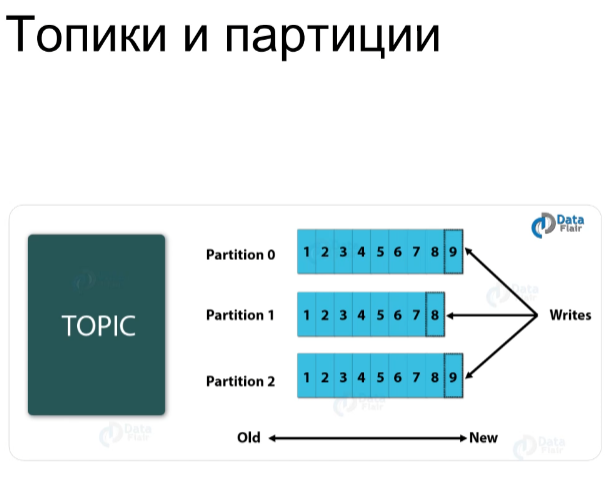

In [7]:
from confluent_kafka import Producer, Consumer

In [6]:
from kafka import KafkaProducer, KafkaConsumer
import json

BOOTSTRAP = ['172.27.110.36:9092']
TOPIC = 'test-topic'

# === Отправка ===
producer = KafkaProducer(
    bootstrap_servers=BOOTSTRAP,
    value_serializer=lambda v: json.dumps(v).encode('utf-8')
)

producer.send(TOPIC, {'message': 'Привет из Jupyter!', 'number': 42})
producer.flush()
print("Сообщение отправлено")

# === Чтение (только новые сообщения) ===
consumer = KafkaConsumer(
    TOPIC,
    bootstrap_servers=BOOTSTRAP,
    auto_offset_reset='latest',          # только новые
    consumer_timeout_ms=5000,
    value_deserializer=lambda m: m.decode('utf-8')   # просто текст
)

print("\nНовые сообщения:")
for msg in consumer:
    print(msg.value)

Сообщение отправлено

Новые сообщения:


C:\Users\n.osipov\AppData\Local\Temp\ipykernel_23032\1822782424.py:18: DeprecationWarning: value_deserializer does not implement kafka.serializer.Deserializer
  consumer = KafkaConsumer(
